# Step 1 — SimNIBS Segmentation (charm)

`charm` (Characterization of Head Anatomy from MR images) is a SimNIBS tool that
builds a detailed tetrahedral head mesh from a T1w structural MRI. It produces
labelled tissue maps used downstream by PlanTUS for transducer placement and by
Brainsight / kWave for acoustic and thermal simulation.

**Typical runtime:** 20–60 min per subject.

**Step 1** &nbsp;|&nbsp; [Step 2 — Mask preparation →](step02_prepare_masks.ipynb)


In [1]:
# Reference card — displays method overview and mask inventory.
# Run this cell once to see all options before running any method cell.
%run z_references/step1_reference.py

In [2]:
# -----------------------------------------------------------------------
# Settings — edit here before running
# -----------------------------------------------------------------------

SITE_CONFIG = "../config/sites/site_RIKEN_AK.yaml"   # path to site YAML
SUB_ID      = "sub-a777"                                # subject ID (with or without 'sub-' prefix)
FIX_QFORM   = True    # run fslorient -copysform2qform before charm (recommended)
N4_CORRECT  = False   # run ANTs N4 bias field correction before charm (recommended for 7T)
DRY_RUN     = False   # set True to print commands without executing

In [3]:

# -----------------------------------------------------------------------
# Imports & path setup
# -----------------------------------------------------------------------

# ── Matplotlib backend — must be set BEFORE any pyplot import ─────────
# Use Agg (non-GUI, file-only) to avoid GUI event-loop conflicts in
# VS Code Jupyter on all platforms (macOS M1, Linux, Windows).
# Figures are rendered to PNG via BytesIO + IPython.display.Image.
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── Imports (stdlib) ──────────────────────────────────────
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

# ── Imports (third-party) ─────────────────────────────────
from matplotlib.colors import ListedColormap
import nibabel as nib
from nilearn import image, plotting
import numpy as np

# ── Config — Python path ──────────────────────────────────
# Make src/ importable; one level up from run/
SRC_DIR = str((Path("../src")).resolve())
if SRC_DIR not in sys.path:sys.path.insert(0, SRC_DIR)

# ── src / utils ───────────────────────────────────────────
from utils import find_t1, load_site_config, normalise_sub_id, resolve_data_dir, resolve_sub_dir

# ── Load config & resolve subject paths ───────────────────
cfg = load_site_config(SITE_CONFIG)
sub_id_full, sub_id_bare = normalise_sub_id(SUB_ID)

data_dir = resolve_data_dir(cfg)
sub_dir  = resolve_sub_dir(data_dir, sub_id_bare, sub_id_full)
m2m_dir  = sub_dir / f"m2m_{sub_id_full}"
t1_path  = find_t1(sub_dir, sub_id_bare)

# FSL fslorient binary (from site config; falls back to PATH)
fsl_bin   = Path(cfg["fsl_bin"]).expanduser()
fslorient = fsl_bin / "fslorient"
if not fslorient.exists():
    fslorient = Path(shutil.which("fslorient") or "fslorient")

print(f"Site:         {cfg.get('site')} / {cfg.get('station')}")
print(f"Segmentation: {cfg.get('segmentation')}")
print(f"Data dir:     {data_dir}")
print(f"Subject:      {sub_id_full}")
print(f"  T1w:        {t1_path}  ({t1_path.stat().st_size / 1e6:.1f} MB)")
print(f"  Output:     {m2m_dir}")
print(f"FSL:          {fslorient}")
if DRY_RUN:
    print("\nMode: DRY RUN")


NOTE: using BIDS-style subject dir: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_TEST/sub-a777
Site:         RIKEN / AK
Segmentation: SimNIBS
Data dir:     /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_TEST
Subject:      sub-a777
  T1w:        /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_TEST/sub-a777/sub-a777_ses-01_acq-memprageRMS_desc-preproc_T1w.nii.gz  (23.5 MB)
  Output:     /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_TEST/sub-a777/m2m_sub-a777
FSL:          /Users/atsushikikumoto/fsl/bin/fslorient


In [ ]:

# -----------------------------------------------------------------------
# Step 1a — Fix qform/sform (optional)
# Run if charm reports a sform/qform mismatch warning.
# -----------------------------------------------------------------------
if FIX_QFORM:
    cmd = [str(fslorient), "-copysform2qform", str(t1_path)]
    print("Running:", " ".join(cmd))
    if not DRY_RUN:
        subprocess.run(cmd, check=True)
        print("Done.")
else:
    print("Skipping qform fix (FIX_QFORM=False)")


In [ ]:

# -----------------------------------------------------------------------
# Step 1b — N4 bias field correction (optional)
# Recommended for 7T data. Corrects intensity inhomogeneity before charm.
# Uses ANTs (available in the mri conda env).
# Set N4_CORRECT=True in Settings to enable.
#
# ⚠️  WARNING: OVERWRITES t1_path IN PLACE
#     The original raw T1w is replaced by the N4-corrected version.
#     All downstream steps (Step03 registration, Brainsight) will use
#     the corrected image automatically. This ensures consistency.
#
#     Back up the raw file before running if you want to preserve it:
#       cp <t1_path> <t1_path>.bak
# -----------------------------------------------------------------------
if N4_CORRECT:
    import ants
    print(f"Running N4 bias field correction on: {t1_path}")
    print("⚠️  Will overwrite original file in place.")
    if DRY_RUN:
        print("DRY RUN — N4 not executed.")
    else:
        t1_ants = ants.image_read(str(t1_path))
        t1_n4   = ants.n4_bias_field_correction(t1_ants)
        ants.image_write(t1_n4, str(t1_path))
        print(f"Done. N4-corrected image written to: {t1_path}")
else:
    print("Skipping N4 bias field correction (N4_CORRECT=False)")


In [ ]:

# -----------------------------------------------------------------------
# Step 1c — Run charm (20–60 min)
# Writes m2m_{sub_id}/ into sub_dir. DRY_RUN=True prints command only.
# -----------------------------------------------------------------------
cmd = ["charm", sub_id_full, str(t1_path)]
print("Running:", " ".join(cmd))
print(f"cwd:     {sub_dir}")

if DRY_RUN:
    print("\nDRY RUN — command not executed.")
else:
    # Use Popen to stream stdout+stderr line-by-line.
    # subprocess.run() in Jupyter buffers all output silently and can block
    # when the pipe fills up during long-running processes like charm.
    n_threads = str(cfg.get("num_threads", 8))
    env = os.environ.copy()
    env["OPENBLAS_NUM_THREADS"] = n_threads  # suppress Rosetta/OpenBLAS warnings on Apple Silicon
    env["OMP_NUM_THREADS"]      = n_threads  # match charm.ini threads setting
    _t0 = time.time()
    with subprocess.Popen(
        cmd, cwd=str(sub_dir),
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, env=env
    ) as proc:
        for line in proc.stdout:
            print(line, end="", flush=True)
        proc.wait()
    _elapsed = time.time() - _t0
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)
    print(f"\ncharm finished in {int(_elapsed // 60)} min {int(_elapsed % 60)} sec.")


In [ ]:

# -----------------------------------------------------------------------
# Step 1d — Verify output
# Checks that expected charm output files exist.
# -----------------------------------------------------------------------
expected = [
    m2m_dir / "final_tissues.nii.gz",
    m2m_dir / "final_tissues_LUT.txt",
    m2m_dir / "T1.nii.gz",
]

print(f"Output: {m2m_dir}")
all_ok = True
for p in expected:
    if p.exists():
        print(f"  [✓] {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"  [✗] {p.name}  — NOT FOUND")
        all_ok = False

print()
print("Output complete — proceed to QA." if all_ok else "Missing files — check charm log above.")


Output: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_TEST/sub-a777/m2m_sub-a777
  [✓] final_tissues.nii.gz  (0.9 MB)
  [✓] final_tissues_LUT.txt  (0.0 MB)
  [✓] T1.nii.gz  (24.6 MB)
  [✓] T1_bias_corrected.nii.gz  (13.1 MB)  ← QA background

Output complete — proceed to QA.


tissues shape: (176, 256, 256)  labels: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10]
Background: T1_bias_corrected.nii.gz


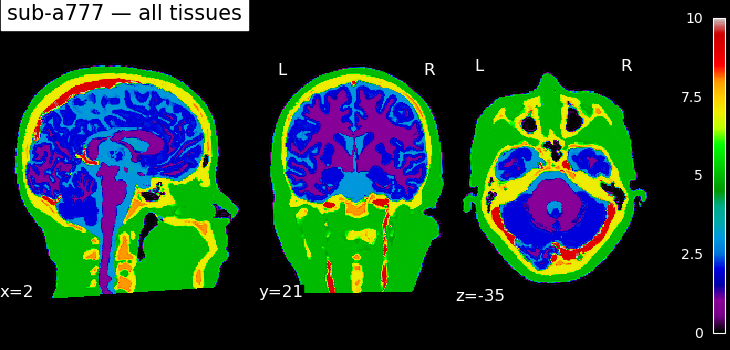

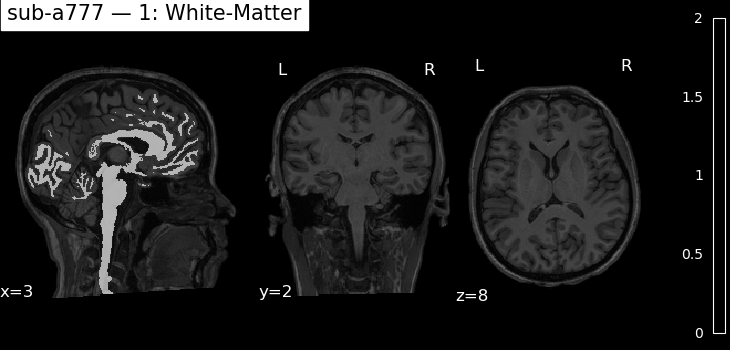

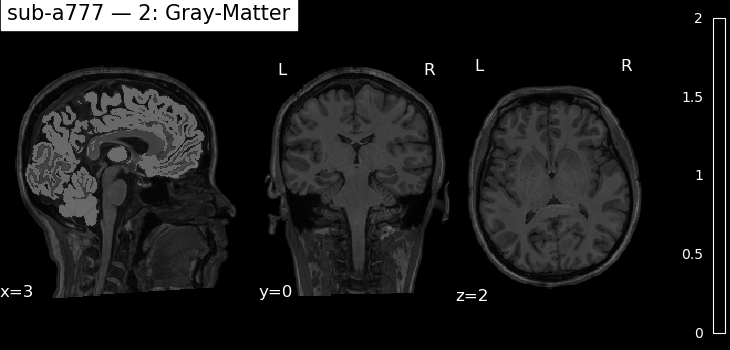

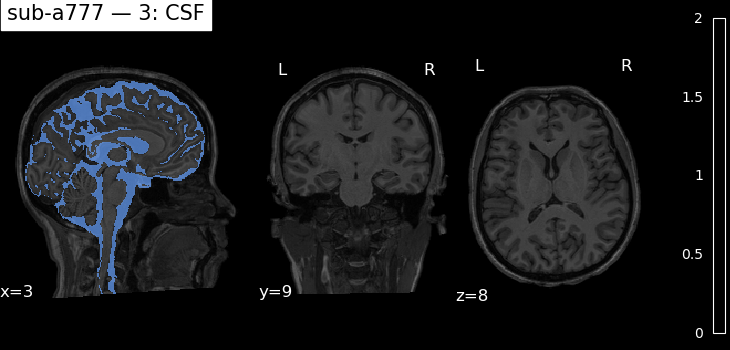

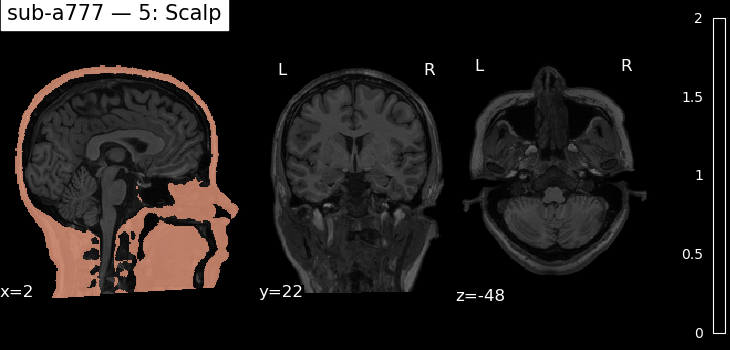

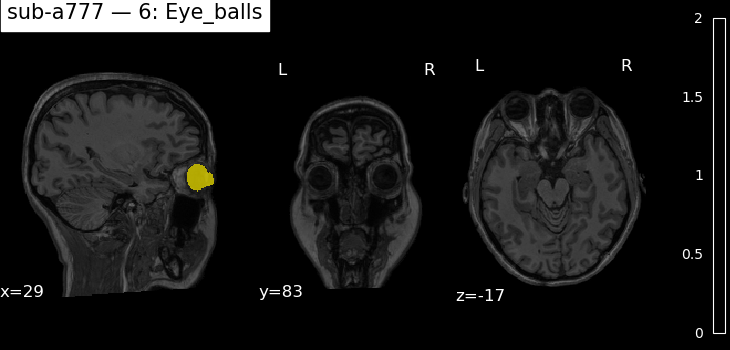

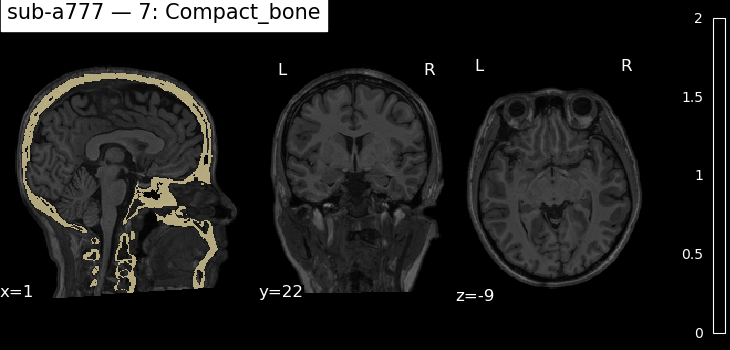

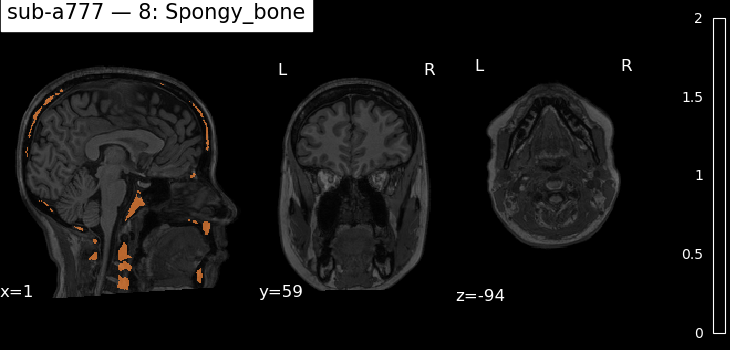

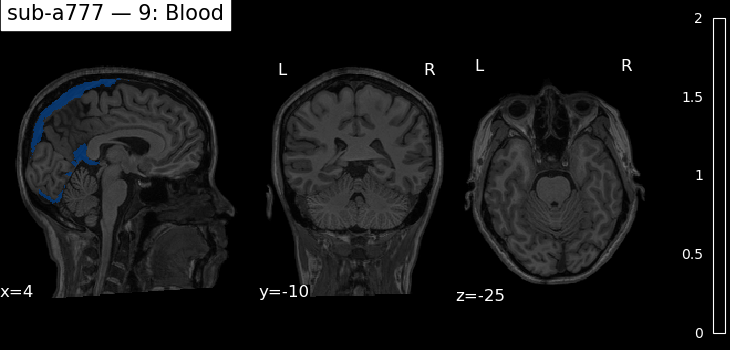

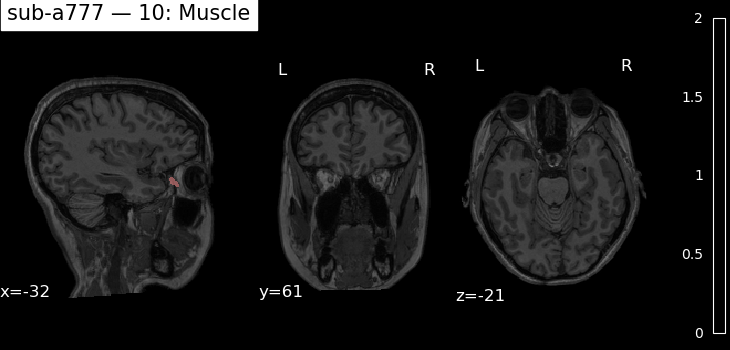

In [ ]:

# -----------------------------------------------------------------------
# Step 1e — QA: visualise segmentation
# -----------------------------------------------------------------------
from IPython.display import Image as IPImage, display
from nilearn import plotting as nlplot

tissue_path = m2m_dir / "final_tissues.nii.gz"
lut_path    = m2m_dir / "final_tissues_LUT.txt"
qa_dir      = m2m_dir / "QA"
qa_dir.mkdir(exist_ok=True)

tissues_img = nib.load(str(tissue_path))
affine      = tissues_img.affine
tissues     = tissues_img.get_fdata().squeeze().astype(np.int16)
print(f"tissues shape: {tissues.shape}  labels: {np.unique(tissues).tolist()}")

# ── Load LUT ─────────────────────────────────────────────
lut = {}
with open(lut_path) as f:
    for line in f:
        parts = line.split()
        if len(parts) < 6 or not parts[0].isdigit():
            continue
        idx  = int(parts[0])
        name = parts[1]
        R, G, B, A = map(int, parts[-4:])
        lut[idx] = {"name": name, "rgba": (R/255, G/255, B/255, A/255)}

# ── Load T1 background ────────────────────────────────────
bg_img = None
for candidate in [
    m2m_dir / "segmentation" / "T1_bias_corrected.nii.gz",
    m2m_dir / "T1.nii.gz",
]:
    if candidate.exists():
        bg_img = nib.load(str(candidate))
        print(f"Background: {candidate.name}")
        break

# ── All-tissues overview ──────────────────────────────────
all_nib = nib.Nifti1Image(tissues.astype(np.float32), affine)
fig = nlplot.plot_stat_map(
    all_nib, bg_img=bg_img,
    display_mode="ortho", draw_cross=False,
    title=f"{sub_id_full} — all tissues",
    colorbar=True, cmap="nipy_spectral",
)
png = qa_dir / "all_tissues_QA.png"
fig.savefig(str(png), dpi=100)
plt.close("all")
display(IPImage(filename=str(png)))

# ── Per-tissue plots ──────────────────────────────────────
for lab in sorted(lut.keys()):
    if lab == 0:
        continue
    mask = (tissues == lab).astype(np.float32)
    if not np.any(mask):
        continue
    roi_nib = nib.Nifti1Image(mask, affine)
    tissue_cmap = ListedColormap([(0, 0, 0, 0), lut[lab]["rgba"]])
    fig = nlplot.plot_roi(
        roi_nib, bg_img=bg_img,
        display_mode="ortho", draw_cross=False,
        title=f"{sub_id_full} — {lab}: {lut[lab]['name']}",
        alpha=0.7,
        cmap=tissue_cmap,
    )
    png = qa_dir / f"tissue_{lab:03d}_{lut[lab]['name']}_QA.png"
    fig.savefig(str(png), dpi=100)
    plt.close("all")
    display(IPImage(filename=str(png)))
